# LotClock — Malaysian used-car listings, and why "days to sell" isn't in here yet

Daily snapshots of a Malaysian used-car index, collected since 2026-07-19.
Two files:

- `lotclock_daily_coverage.csv` — one row per collection day: how much of the site
  was actually harvested. Read this **before** the listings file.
- `lotclock_listings.csv` — one row per listing in the full-census era, with
  `duration_obs_days` / `event_exited` for survival analysis.

This notebook does three things: shows the coverage honestly, measures price cuts,
and then demonstrates why the days-on-market question is **not answerable yet** —
99.9% right-censoring. That last part is the useful bit; most public analyses of
listing data quietly report the median of the sold-and-observed cars and call it
"time to sell", which is survivorship bias with a number attached.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
from pathlib import Path
# runs on Kaggle and locally: the input mount if it exists, else this folder
D = Path('/kaggle/input/malaysian-used-car-listings-daily-snapshots')
if not D.exists():
    D = Path('.')
cov = pd.read_csv(D / 'lotclock_daily_coverage.csv', parse_dates=['date'])
df  = pd.read_csv(D / 'lotclock_listings.csv')
print(cov.shape, df.shape)
cov.tail(12)

(25, 4) (13099, 15)


,date,listings_seen,coverage_era,is_observation_day
13,2026-08-05,2005,partial_15pct,0
14,2026-08-07,2009,partial_15pct,0
15,2026-08-08,2105,partial_15pct,0
16,2026-08-09,12392,full_census,1
17,2026-08-10,12370,full_census,1
18,2026-08-11,8153,full_census,0
19,2026-08-12,12649,full_census,1
20,2026-08-14,12378,full_census,1
21,2026-08-15,4097,full_census,0
22,2026-08-16,11702,full_census,1


## 1. Coverage first

The crawl hit its page cap until 2026-08-09, harvesting ~15% of the site. From
2026-08-09 it walks to exhaustion (~12,400 listings). Those are two different
sampling regimes and pooling them would invent thousands of fake disappearances.
A few census runs were also killed mid-walk; they are flagged
`is_observation_day = 0` and must be dropped, not treated as light days.

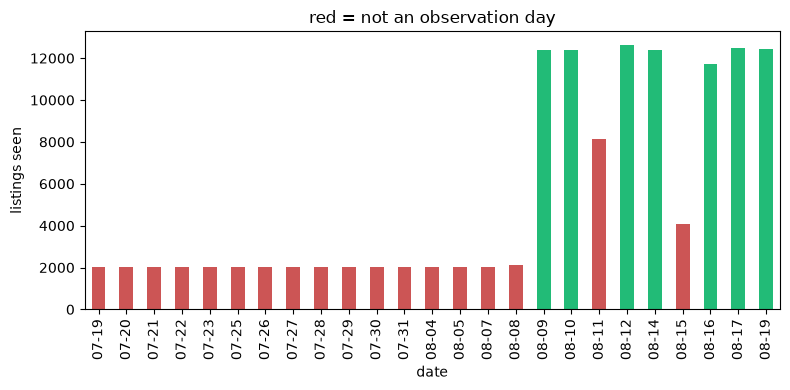

,count,median
coverage_era,,
full_census,9,12378.0
partial_15pct,16,2012.0


In [2]:
ax = cov.plot.bar(x='date', y='listings_seen', legend=False,
                  color=np.where(cov.is_observation_day == 1, '#2b7', '#c55'))
ax.set_xticklabels([d.strftime('%m-%d') for d in cov.date], rotation=90)
ax.set_ylabel('listings seen'); ax.set_title('red = not an observation day')
plt.tight_layout(); plt.show()
cov.groupby('coverage_era').listings_seen.agg(['count', 'median'])

## 2. What this sample actually is

Not "the Malaysian used-car market". It is one dealer-heavy index, and it skews
premium and Klang-Valley. Say so before quoting any median.

median asking price: RM 181,250


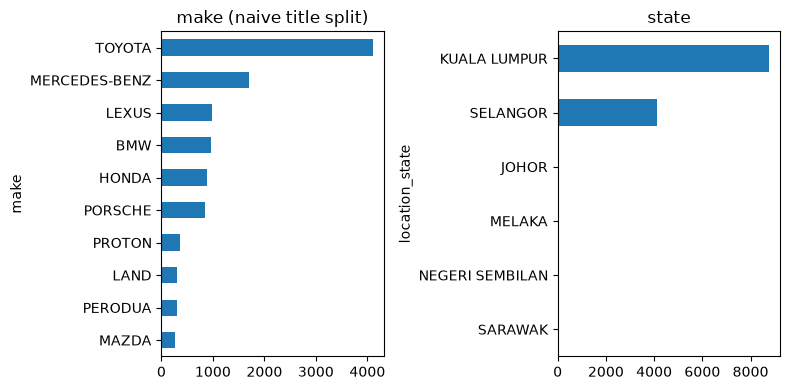

In [3]:
print('median asking price: RM {:,.0f}'.format(df.first_price_myr.median()))
fig, axes = plt.subplots(1, 2)
df.make.value_counts().head(10).plot.barh(ax=axes[0], title='make (naive title split)')
df.location_state.value_counts().head(6).plot.barh(ax=axes[1], title='state')
for a in axes: a.invert_yaxis()
plt.tight_layout(); plt.show()

Note `LAND` in the make chart: makes are the second token of the title, so
"LAND ROVER" splits. Fix it with a marque list if you need clean makes.

## 3. Price cuts

Append-only snapshots mean a price change is a new dated row, so cuts are directly
observable — this is the part of the dataset that works today.

122 of 13,074 listings cut price (0.9%) over 7 observation days
median cut: RM 5,000


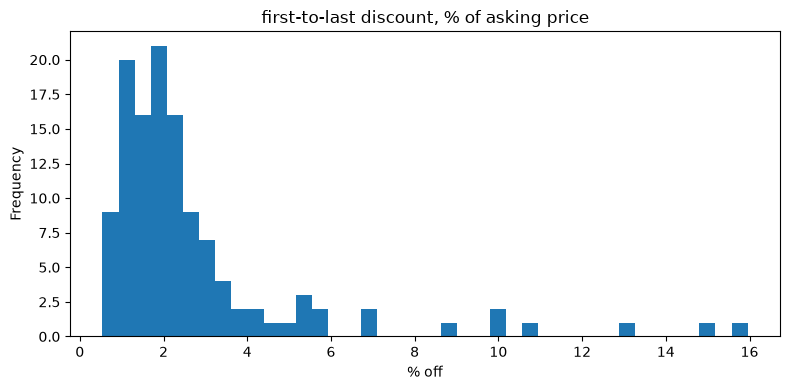

In [4]:
multi = df[df.observed_days_seen > 1]
cut = multi[multi.price_cut_myr > 0]
print(f'{len(cut):,} of {len(multi):,} listings cut price ({len(cut)/len(multi):.1%}) '
      f'over {int(cov.is_observation_day.sum())} observation days')
print('median cut: RM {:,.0f}'.format(cut.price_cut_myr.median()))
(cut.price_cut_myr / cut.first_price_myr * 100).plot.hist(bins=40,
    title='first-to-last discount, % of asking price')
plt.xlabel('% off'); plt.tight_layout(); plt.show()

## 4. Survival — and the censoring wall

`event_exited = 1` means the listing was absent for 5 consecutive observation days,
the threshold at which absences stop reversing. A listing vanishing for one day
usually comes back: the site reorders under the crawl. Kaplan–Meier, hand-rolled
so there is no dependency to argue with:

In [5]:
def km(duration, event):
    t = np.sort(np.unique(duration[event == 1]))
    s, out = 1.0, []
    for ti in t:
        at_risk = (duration >= ti).sum()
        d = ((duration == ti) & (event == 1)).sum()
        s *= 1 - d / at_risk
        out.append((ti, s, at_risk, d))
    return pd.DataFrame(out, columns=['t_obs_days', 'survival', 'at_risk', 'events'])

curve = km(df.duration_obs_days.values, df.event_exited.values)
print('events:', int(df.event_exited.sum()), ' censored: '
      f'{1 - df.event_exited.mean():.1%}')
curve

events: 7  censored: 99.9%


,t_obs_days,survival,at_risk,events
0,1,0.999924,13099,1
1,2,0.999465,13074,6


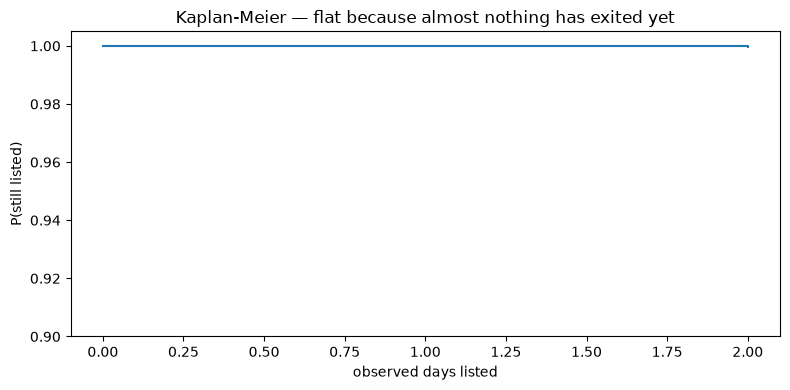

In [6]:
plt.step(np.r_[0, curve.t_obs_days], np.r_[1, curve.survival], where='post')
plt.ylim(0.9, 1.005); plt.xlabel('observed days listed'); plt.ylabel('P(still listed)')
plt.title('Kaplan-Meier — flat because almost nothing has exited yet')
plt.tight_layout(); plt.show()

**The honest conclusion.** With 7 observation days and a 5-day exit rule, only a
listing last seen on day 1 or 2 can register as exited. 99.9% of rows are
right-censored, so the median days-on-market is not estimable — any number you
compute from the observed exits is a survivorship artefact.

What is estimable today: coverage, the asking-price distribution, and price-cut
behaviour. Days-on-market becomes answerable as the observation window grows;
the dataset is updated as collection continues.

**If you fork this:** don't pool the two coverage eras, don't drop
`is_observation_day = 0` rows into the duration maths, and don't read
`event_exited = 1` as "sold" — a delisting can be a sale, an expiry, or a seller
giving up.